In [ ]:
from google.colab import drive
import os

# 1. Mount the Google Drive
drive.mount('/content/drive')

# 2. Define the exact path to the shared project folder
PROJECT_ROOT = '/content/drive/MyDrive/MNIST-Project/'

# 3. Automatically create the required sub-folders if they don't exist yet
os.makedirs(os.path.join(PROJECT_ROOT, 'data'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'models'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'results'), exist_ok=True)

print("Drive successfully mounted and project directories are ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive successfully mounted and project directories are ready!


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import polynomial_kernel, rbf_kernel

data_dir = os.path.join(PROJECT_ROOT, 'data')
models_dir = os.path.join(PROJECT_ROOT, 'models')

# Load the raw testing data and labels
print("Loading data...")
x_test_2d = np.load(os.path.join(data_dir, 'x_test_2d.npy')).reshape(-1, 28, 28, 1)
x_test_flat = np.load(os.path.join(data_dir, 'x_test_flat.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

# Define the kernel before loading
def hybrid_kernel(X, Y):
    poly_matrix = polynomial_kernel(X, Y, degree=3, gamma=1.0, coef0=1.0)
    rbf_matrix = rbf_kernel(X, Y, gamma=0.01)
    return (0.7 * poly_matrix) + (0.3 * rbf_matrix)

# Load the Models
print("Loading saved models...")
cnn_model = tf.keras.models.load_model(os.path.join(models_dir, 'advanced_cnn.keras'))
svm_model = joblib.load(os.path.join(models_dir, 'hybrid_svm_15k.pkl'))

# Recreate the exact PCA mapping
print("Recreating PCA mapping for the SVM...")
x_train_full_flat = np.load(os.path.join(data_dir, 'x_train_full_flat.npy'))
pca = PCA(n_components=0.85)
pca.fit(x_train_full_flat)
print("Setup Complete! Models are locked and loaded.")

Loading data...
Loading saved models...
Recreating PCA mapping for the SVM...
Setup Complete! Models are locked and loaded.


In [ ]:
def add_gaussian_noise(images, noise_factor=0.3):
    """Adds random static to images and keeps pixel values valid (0 to 1)."""
    # Generate random noise matrix in the exact shape of the images
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=images.shape)
    noisy_images = images + noise

    # Clip values so they don't go below 0 (black) or above 1 (white)
    return np.clip(noisy_images, 0., 1.)

print("\nApplying Gaussian Noise to the Test Dataset...")
# Create noisy 2D data for the CNN
x_test_noisy_2d = add_gaussian_noise(x_test_2d, noise_factor=0.3)

# Create noisy Flat data, then compress it with PCA for the SVM
x_test_noisy_flat = x_test_noisy_2d.reshape(-1, 784)
x_test_noisy_pca = pca.transform(x_test_noisy_flat)

# Also get clean PCA data for the baseline comparison
x_test_clean_pca = pca.transform(x_test_flat)

print("Noise generation and PCA compression complete!")


Applying Gaussian Noise to the Test Dataset...
Noise generation and PCA compression complete!


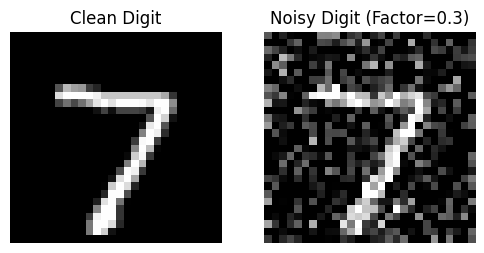

In [ ]:
# Visualize the corruption
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title("Clean Digit")
plt.imshow(x_test_2d[0].reshape(28, 28), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Noisy Digit (Factor=0.3)")
plt.imshow(x_test_noisy_2d[0].reshape(28, 28), cmap='gray')
plt.axis('off')

# Save the image to Drive
plt.savefig(os.path.join(PROJECT_ROOT, 'results', 'noise_comparison.png'), bbox_inches='tight')
plt.show()

In [ ]:
print("--- Final Robustness Evaluation ---")

# 1. Test SVM (Clean vs Noisy)
print("\nTesting Hybrid SVM...")
svm_clean_acc = accuracy_score(y_test, svm_model.predict(x_test_clean_pca))
svm_noisy_acc = accuracy_score(y_test, svm_model.predict(x_test_noisy_pca))
svm_drop = svm_clean_acc - svm_noisy_acc

# 2. Test CNN (Clean vs Noisy)
print("Testing Advanced CNN...")
cnn_clean_preds = np.argmax(cnn_model.predict(x_test_2d, verbose=0), axis=1)
cnn_noisy_preds = np.argmax(cnn_model.predict(x_test_noisy_2d, verbose=0), axis=1)

cnn_clean_acc = accuracy_score(y_test, cnn_clean_preds)
cnn_noisy_acc = accuracy_score(y_test, cnn_noisy_preds)
cnn_drop = cnn_clean_acc - cnn_noisy_acc

print(f"\n--- Final Results ---")
print(f"SVM Clean: {svm_clean_acc*100:.2f}%  |  SVM Noisy: {svm_noisy_acc*100:.2f}%  |  Drop: {svm_drop*100:.2f}%")
print(f"CNN Clean: {cnn_clean_acc*100:.2f}%  |  CNN Noisy: {cnn_noisy_acc*100:.2f}%  |  Drop: {cnn_drop*100:.2f}%")

--- Final Robustness Evaluation ---

Testing Hybrid SVM...
Testing Advanced CNN...

--- Final Results ---
SVM Clean: 97.68%  |  SVM Noisy: 81.00%  |  Drop: 16.68%
CNN Clean: 99.29%  |  CNN Noisy: 95.59%  |  Drop: 3.70%


--- Generating Final Confusion Matrices ---


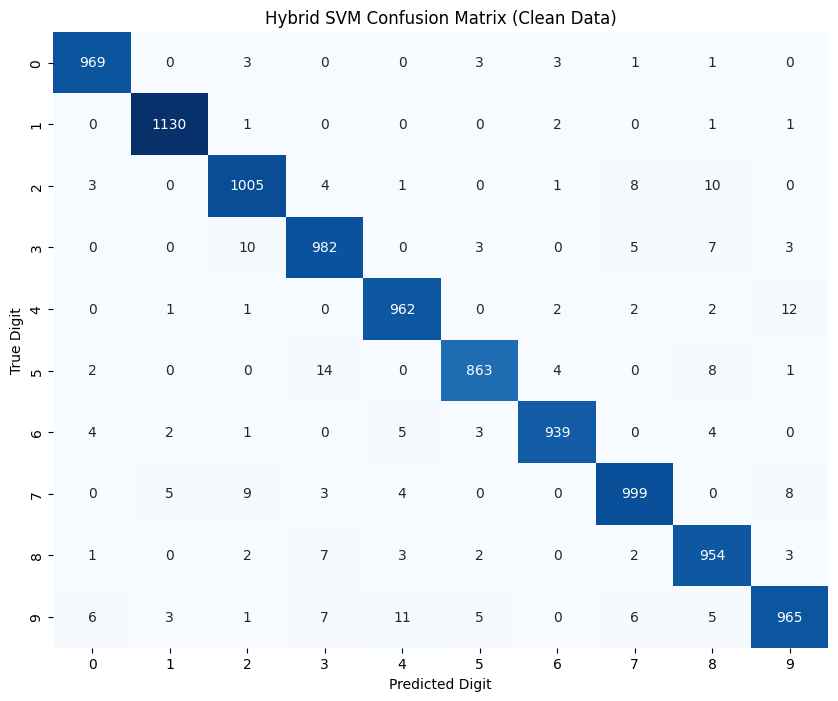

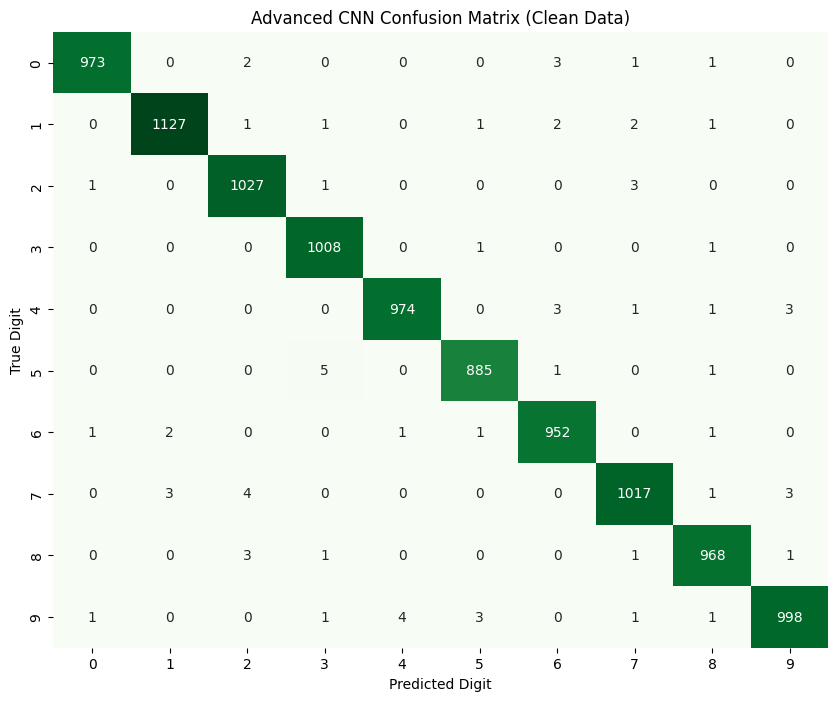

Confusion Matrices successfully saved to the 'results' folder!


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("--- Generating Final Confusion Matrices ---")

# 1. Get predictions on the clean test data
svm_clean_preds = svm_model.predict(x_test_clean_pca)
cnn_clean_preds = np.argmax(cnn_model.predict(x_test_2d, verbose=0), axis=1)

# 2. Calculate the math matrices
cm_svm = confusion_matrix(y_test, svm_clean_preds)
cm_cnn = confusion_matrix(y_test, cnn_clean_preds)

# 3. Plot and Save SVM Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Hybrid SVM Confusion Matrix (Clean Data)')
plt.ylabel('True Digit')
plt.xlabel('Predicted Digit')
plt.savefig(os.path.join(PROJECT_ROOT, 'results', 'svm_confusion.png'), bbox_inches='tight')
plt.show()

# 4. Plot and Save CNN Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Advanced CNN Confusion Matrix (Clean Data)')
plt.ylabel('True Digit')
plt.xlabel('Predicted Digit')
plt.savefig(os.path.join(PROJECT_ROOT, 'results', 'cnn_confusion.png'), bbox_inches='tight')
plt.show()

print("Confusion Matrices successfully saved to the 'results' folder!")